# 📘 S7_P2 — Risque de crédit : Arbre, Gradient Boosting, ROC & SHAP

## 🎯 Le problème : prédire le risque de crédit
Une banque veut savoir, **avant d'accorder un prêt**, si l'emprunteur va **faire défaut** (ne pas rembourser). La cible est `loan_status` : **0 = rembourse, 1 = défaut**. C'est une **classification binaire**, avec un déséquilibre à surveiller (~78 % / 22 %).

## 🗺️ Le plan de ce notebook
1. **Préparer les données** : encoder le texte en nombres, traiter les valeurs manquantes
2. **Un premier modèle** : l'arbre de décision, puis l'optimiser avec GridSearch
3. **Le Gradient Boosting** : un modèle d'ensemble plus puissant
4. **Évaluer finement** : la courbe ROC et l'AUC (au-delà de l'accuracy)
5. **Expliquer** les prédictions avec **SHAP**

---
Import de pandas + chargement du dataset (32 581 emprunteurs).

In [1]:
import pandas as pd

## 🧠 Préparer les données : transformer le texte en nombres

Un modèle ne calcule qu'avec des **nombres**. Les colonnes texte doivent donc être converties. Trois techniques selon le type de variable :

| Technique | Pour quoi | Exemple |
|---|---|---|
| **`.map({...})`** | 2 valeurs (binaire) | `cb_person_default_on_file` : "Y"→1, "N"→0 |
| **`.cat.codes`** | catégories ORDONNÉES | `loan_grade` : A→0, B→1, … G→6 (une note a un ordre !) |
| **`get_dummies`** | catégories SANS ordre | `person_home_ownership` : RENT/OWN/MORTGAGE → colonnes 0/1 |

`pd.get_dummies(df, drop_first=True)` applique le one-hot encoding à **toutes** les colonnes texte d'un coup. `drop_first=True` supprime une colonne par variable pour éviter la redondance (le « dummy variable trap », cf. S2_P4).

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [3]:
df["person_home_ownership"]

0            RENT
1             OWN
2        MORTGAGE
3            RENT
4            RENT
           ...   
32576    MORTGAGE
32577    MORTGAGE
32578        RENT
32579    MORTGAGE
32580        RENT
Name: person_home_ownership, Length: 32581, dtype: str

In [4]:
pd.get_dummies(df[["person_home_ownership"]], drop_first=True) 

,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
0,False,False,True
1,False,True,False
2,False,False,False
3,False,False,True
4,False,False,True
...,...,...,...
32576,False,False,False
32577,False,False,False
32578,False,False,True
32579,False,False,False


In [5]:
df["loan_grade"].unique()

<ArrowStringArray>
['D', 'B', 'C', 'A', 'E', 'F', 'G']
Length: 7, dtype: str

In [6]:
df["loan_grade"].astype("category").cat.codes

0        3
1        1
2        2
3        2
4        2
        ..
32576    2
32577    0
32578    1
32579    1
32580    1
Length: 32581, dtype: int8

In [7]:
df["cb_person_default_on_file"].map({"Y" : 1,"N" : 0 })

0        1
1        0
2        0
3        0
4        1
        ..
32576    0
32577    0
32578    0
32579    0
32580    0
Name: cb_person_default_on_file, Length: 32581, dtype: int64

In [8]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [9]:
df = pd.get_dummies(df, drop_first=True)

In [10]:
df

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,30,False,False,...,False,True,False,False,True,False,False,False,False,False
32577,54,120000,4.0,17625,7.49,0,0.15,19,False,False,...,False,True,False,False,False,False,False,False,False,False
32578,65,76000,3.0,35000,10.99,1,0.46,28,False,False,...,False,False,False,True,False,False,False,False,False,False
32579,56,150000,5.0,15000,11.48,0,0.10,26,False,False,...,False,True,False,True,False,False,False,False,False,False


## 🧠 Les valeurs manquantes (`NaN`)

`isna().sum()` compte les trous par colonne : ici **`person_emp_length`** (895) et **`loan_int_rate`** (3116) en ont.

Deux stratégies : **imputer** (remplacer par la moyenne/médiane, cf. Titanic S2_P4) ou **`dropna()`** (supprimer les lignes trouées). Ici on utilise `dropna()` — radical mais simple : on perd ~4000 lignes sur 32 581, ce qui reste acceptable vu la taille.

💡 **À remarquer :** `person_emp_length` a un maximum de **123 ans** d'ancienneté — impossible ! C'est une **valeur aberrante** (outlier) qui traîne. On la garde ici, mais dans un vrai projet il faudrait la corriger.

In [11]:
df.isna().sum()

person_age                        0
person_income                     0
person_emp_length               895
loan_amnt                         0
loan_int_rate                  3116
loan_status                       0
loan_percent_income               0
cb_person_cred_hist_length        0
person_home_ownership_OTHER       0
person_home_ownership_OWN         0
person_home_ownership_RENT        0
loan_intent_EDUCATION             0
loan_intent_HOMEIMPROVEMENT       0
loan_intent_MEDICAL               0
loan_intent_PERSONAL              0
loan_intent_VENTURE               0
loan_grade_B                      0
loan_grade_C                      0
loan_grade_D                      0
loan_grade_E                      0
loan_grade_F                      0
loan_grade_G                      0
cb_person_default_on_file_Y       0
dtype: int64

In [12]:
df["person_emp_length"].describe()

count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

In [13]:
df[["person_emp_length"]]

,person_emp_length
0,123.0
1,5.0
2,1.0
3,4.0
4,8.0
...,...
32576,1.0
32577,4.0
32578,3.0
32579,5.0


In [14]:
len(df[["person_emp_length"]].dropna())

31686

In [15]:
df = df.dropna()

In [16]:
df

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,30,False,False,...,False,True,False,False,True,False,False,False,False,False
32577,54,120000,4.0,17625,7.49,0,0.15,19,False,False,...,False,True,False,False,False,False,False,False,False,False
32578,65,76000,3.0,35000,10.99,1,0.46,28,False,False,...,False,False,False,True,False,False,False,False,False,False
32579,56,150000,5.0,15000,11.48,0,0.10,26,False,False,...,False,True,False,True,False,False,False,False,False,False


## Étape — Séparer features / cible, puis train / test

`X` = toutes les colonnes sauf `loan_status` ; `y` = `loan_status`. Puis `train_test_split` réserve 20 % pour l'évaluation finale (le workflow habituel depuis S1).

In [17]:
X = df.drop("loan_status",axis=1)
y = df["loan_status"]

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)


## TRAIN 1  : (DecisionTree)

## 🌳 Premier modèle : l'arbre de décision

`DecisionTreeClassifier(max_depth=20)` : un arbre profond (cf. théorie S4_P2 — questions binaires, impureté de Gini). Sur des données de crédit déséquilibrées, on regardera surtout le **rappel de la classe 1** (les défauts) : rater un mauvais payeur coûte cher à la banque !

In [20]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(max_depth=20,random_state=32)
DT.fit(X_train, y_train)
y_pred_DT = DT.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

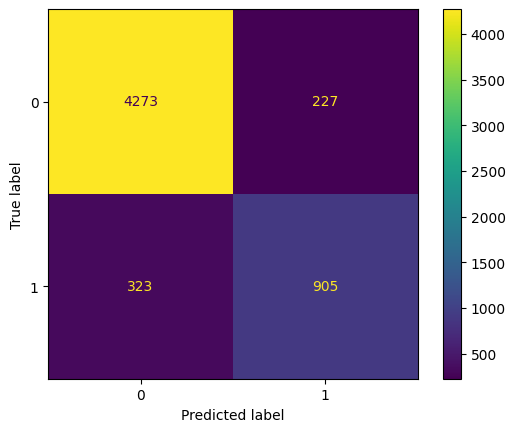

In [21]:
ConfusionMatrixDisplay.from_estimator(DT,X_test,y_test)

In [22]:
print(classification_report(y_test, y_pred_DT))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4500
           1       0.80      0.74      0.77      1228

    accuracy                           0.90      5728
   macro avg       0.86      0.84      0.85      5728
weighted avg       0.90      0.90      0.90      5728



In [23]:
from sklearn.model_selection import GridSearchCV

## 🧠 GridSearchCV avec PLUSIEURS métriques

Nouveauté par rapport à S6 : on optimise sur **plusieurs scores à la fois**.
```python
scoring={"Recall": "recall", "Accuracy": "accuracy"}, refit="Recall"
```
- `scoring={...}` : calcule le rappel ET l'accuracy pour chaque combinaison,
- **`refit="Recall"`** : mais choisit le meilleur modèle selon le **rappel** (la métrique qui compte pour la banque : détecter les défauts).

Rappel : `cv=5` = validation croisée sur 5 découpages → un score robuste.

In [24]:
dt =  DecisionTreeClassifier(random_state=32)

In [25]:
param_grid = {"max_depth": [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30]}
grid = GridSearchCV(estimator=dt,param_grid =param_grid,cv =5,scoring={"Recall":"recall","Accuracy": "accuracy"},refit="Recall")

In [26]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'Accuracy': 'accuracy', 'Recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'Recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also 

In [27]:
grid_result = pd.DataFrame(grid.cv_results_)

In [28]:
grid.best_params_

{'max_depth': 30}

In [29]:
results =  grid_result[['param_max_depth',"mean_test_Recall","mean_test_Accuracy"]]

<Axes: xlabel='param_max_depth'>

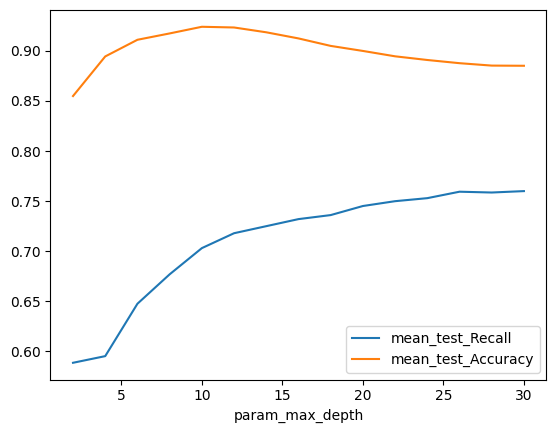

In [30]:
results.plot(x = "param_max_depth")

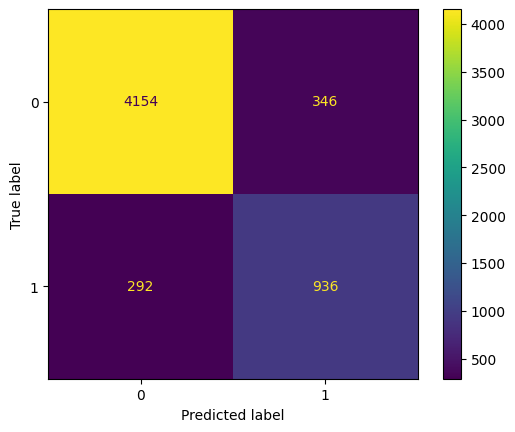

In [31]:
ConfusionMatrixDisplay.from_estimator(grid,X_test,y_test)

In [32]:
y_pred_dt_best = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_dt_best))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      4500
           1       0.73      0.76      0.75      1228

    accuracy                           0.89      5728
   macro avg       0.83      0.84      0.84      5728
weighted avg       0.89      0.89      0.89      5728



In [33]:
from sklearn.ensemble import GradientBoostingClassifier

## 🚀 Gradient Boosting : les arbres qui se corrigent

Différence clé avec la forêt : le boosting construit les arbres **l'un après l'autre**, chacun corrigeant les erreurs du précédent (séquentiel, pas parallèle).

⚠️ **Règle d'or du boosting :** les arbres doivent être **FAIBLES et peu profonds** (`max_depth` 2 à 5) ! Un `max_depth=30` en boosting est un contresens — chaque arbre devient énorme et lent. `learning_rate` contrôle la « prudence » de chaque correction (petit = apprentissage lent mais précis).

✅ Version corrigée : `max_depth=3` (les arbres faibles qu'exige le boosting), au lieu du 30 initial qui rendait tout interminable.

In [34]:
GB = GradientBoostingClassifier(max_depth=3,random_state=32)
GB.fit(X_train,y_train)
y_pred_gb = GB.predict(X_test)

In [35]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      4500
           1       0.92      0.68      0.79      1228

    accuracy                           0.92      5728
   macro avg       0.92      0.83      0.87      5728
weighted avg       0.92      0.92      0.92      5728



In [36]:
GB.predict_proba(X_test)[54]

array([0.85111789, 0.14888211])

## 🧠 `predict_proba` : la PROBABILITÉ derrière la décision

`predict()` renvoie 0 ou 1. Mais en dessous, le modèle calcule une **probabilité** : `predict_proba(X)` renvoie deux colonnes `[P(classe 0), P(classe 1)]`.

`predict_proba(X)[:, 1]` = la probabilité de défaut. Par défaut, si elle dépasse **0.5** → classe 1. Mais ce seuil peut se déplacer ! Pour une banque prudente, on pourrait alerter dès 0.3 de probabilité de défaut. C'est exactement ce que la **courbe ROC** va explorer.

In [37]:
GB.predict(X_test)[54]

np.int64(0)

In [38]:
y_prob = GB.predict_proba(X_test)

In [39]:
y_prob = GB.predict_proba(X_test)[:,1]

In [40]:
y_prob = GB.predict_proba(X_test)[:,1]

In [41]:
from sklearn.metrics import roc_curve,roc_auc_score

## 🧠 THÉORIE — La courbe ROC et l'AUC (nouvelle métrique clé)

L'accuracy dépend d'UN seuil (0.5). La **courbe ROC** montre la performance à **TOUS les seuils possibles** d'un coup.

`roc_curve(y_test, y_prob)` renvoie 3 tableaux :
- **FPR** (*False Positive Rate*) = taux de faux positifs = bons payeurs classés à tort « défaut »,
- **TPR** (*True Positive Rate*) = taux de vrais positifs = **le rappel** = défauts correctement détectés,
- **thresholds** = le seuil correspondant à chaque point.

**🔍 Comment lire la courbe (TPR en Y, FPR en X) :**
- Chaque point = un seuil différent. En baissant le seuil, on détecte plus de défauts (TPR ↑) mais on lève plus de fausses alertes (FPR ↑).
- Une courbe qui **grimpe vite vers le coin haut-gauche** = un bon modèle (beaucoup de détections, peu de fausses alertes).
- La **diagonale** = un modèle qui répond au hasard.

**L'AUC** (*Area Under the Curve*, `roc_auc_score`) résume tout en UN chiffre = l'aire sous la courbe :
- **AUC = 1.0** : modèle parfait,
- **AUC = 0.5** : hasard pur,
- **AUC > 0.9** : excellent.

C'est LA métrique de référence pour comparer des classifieurs, surtout sur données déséquilibrées (contrairement à l'accuracy, elle ne se laisse pas berner par la classe majoritaire).

In [42]:
fpr, tpr, threshold = roc_curve(y_test,y_prob)

In [43]:
fpr

array([0.        , 0.        , 0.        , ..., 0.99888889, 0.99933333,
       1.        ], shape=(1754,))

In [44]:
threshold

array([       inf, 0.99971473, 0.99652277, ..., 0.00289428, 0.00281307,
       0.00236188], shape=(1754,))

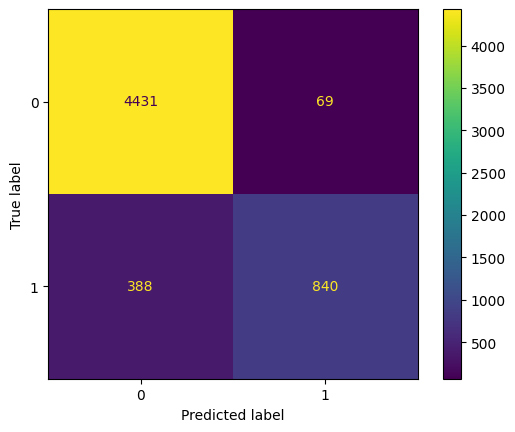

In [45]:
ConfusionMatrixDisplay.from_estimator(GB,X_test,y_test)

In [46]:
roc_data = pd.DataFrame({"False Positive Rate" : fpr ,"True Positive Rate": tpr, "threshold" : threshold})

In [47]:
import plotly.express as px

In [48]:
fig = px.line(
    roc_data,
    x="False Positive Rate",
    y="True Positive Rate",
    hover_data=["threshold"],
    title="ROC Curve"
)

In [49]:
fig.show()

In [50]:
GB = GradientBoostingClassifier(random_state=32)
param_grid = {"max_depth" : [2,3,4], "n_estimators" : [50,100,150],"learning_rate" : [0.05,0.1]}

## GridSearch optimisé sur l'AUC

Ici on ajoute `"ROC_AUC": "roc_auc"` au scoring et `refit="ROC_AUC"` : le meilleur modèle est choisi sur l'**aire sous la courbe ROC** — le critère le plus fiable pour ce problème déséquilibré.

⚠️ Attention à l'orthographe : c'est **AUC** (Area Under Curve), pas « AUX ». (Une coquille `ROC_AUX` fonctionne quand même car c'est juste une étiquette, mais autant l'écrire juste.)

✅ **Corrigé :** grille allégée (`max_depth [2,3,4]`, arbres faibles) + `n_jobs=-1` (parallélisation) + `verbose=1` (progression visible) + `ROC_AUC` bien orthographié. Résultat : ~30 s au lieu de ~27 min !

In [51]:
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=32),
    param_grid=param_grid,
    cv=5,
    scoring={"Recall": "recall", "Accuracy": "accuracy", "ROC_AUC": "roc_auc"},
    refit="ROC_AUC",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'Accuracy': 'accuracy', 'ROC_AUC': 'roc_auc', 'Recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'ROC_AUC'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [52]:
results = pd.DataFrame(grid_search.cv_results_)

In [53]:
selected_results = results[['param_max_depth','param_n_estimators',"mean_test_Recall","mean_test_Accuracy","mean_test_ROC_AUC"]]

In [54]:
selected_results

,param_max_depth,param_n_estimators,mean_test_Recall,mean_test_Accuracy,mean_test_ROC_AUC
0,2,50,0.479598,0.875295,0.886376
1,2,100,0.611859,0.896072,0.905816
2,2,150,0.645628,0.903274,0.911799
3,3,50,0.616884,0.902357,0.904907
4,3,100,0.670754,0.912178,0.917899
5,3,150,0.686834,0.917722,0.923045
6,4,50,0.640201,0.913619,0.915671
7,4,100,0.697688,0.923090,0.926612
8,4,150,0.714774,0.927848,0.932228
9,2,50,0.615075,0.897163,0.906051


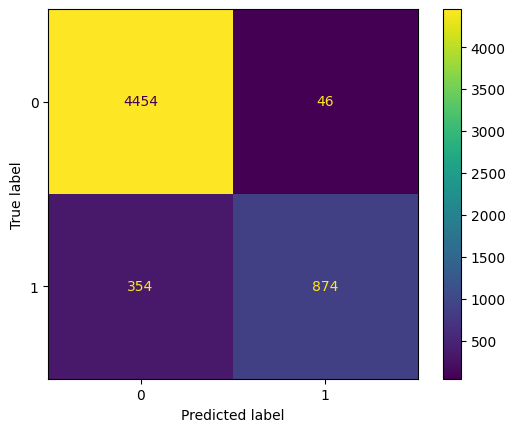

In [55]:
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_,X_test,y_test)

In [56]:
import shap

## 🧠 THÉORIE — SHAP : expliquer une prédiction individuelle

Un modèle d'ensemble est une « boîte noire » : il prédit bien, mais **pourquoi** a-t-il refusé CE crédit précis ? SHAP (*SHapley Additive exPlanations*) répond, en s'appuyant sur la théorie des jeux (les valeurs de Shapley).

- `shap.TreeExplainer(model)` : crée un « explicateur » optimisé pour les arbres/forêts,
- `explainer(X)` : calcule, pour chaque prédiction, la **contribution de chaque variable** (combien elle a poussé la décision vers « défaut » ou « remboursement »).

**Le graphique `waterfall`** (cascade) explique **UN client** : il part de la valeur moyenne et empile les contributions de chaque feature (en rouge = pousse vers le défaut, en bleu = vers le remboursement) jusqu'à la prédiction finale. C'est l'**explicabilité individuelle** — essentielle en banque, où l'on doit justifier chaque refus de crédit.

In [57]:
best_model = grid_search.best_estimator_

In [58]:
explainer = shap.TreeExplainer(best_model)

In [59]:
small_test = X_test 

In [60]:
best_model.predict(X_test)[:20]


array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0])

In [61]:
shap_values = explainer(X_test[:20])

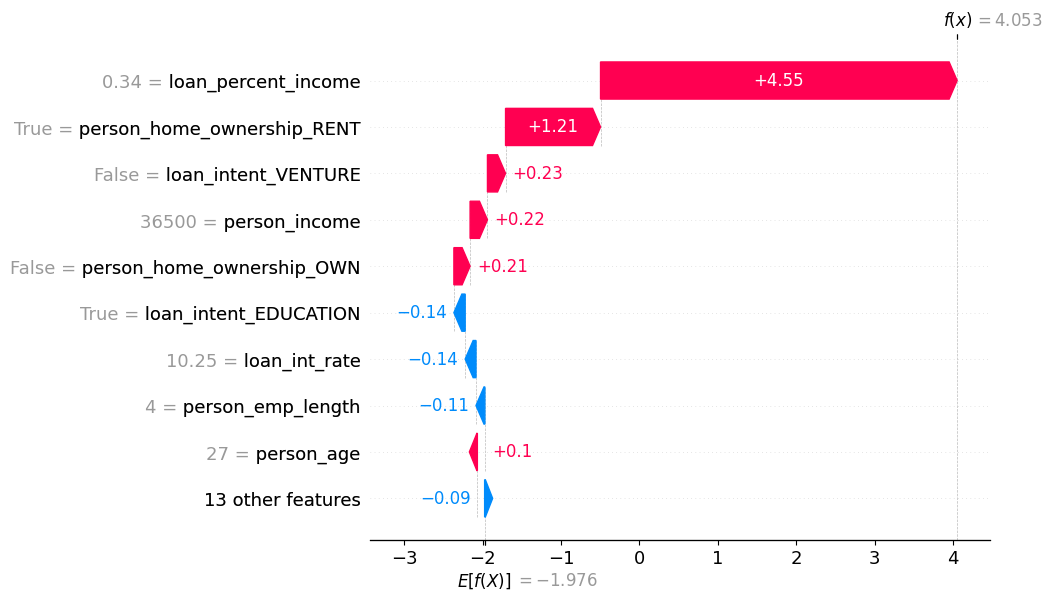

In [63]:
shap.plots.waterfall(shap_values[18])